In [3]:

import matplotlib.pyplot as plt
import numpy as np
from brainglobe_atlasapi import BrainGlobeAtlas

from brainglobe_registration.similarity_metrics import (
    compare_image_to_atlas_slices,
    find_best_atlas_slice,
    mutual_information,
    normalized_cross_correlation,
    structural_similarity_index,
)

(318, 428)


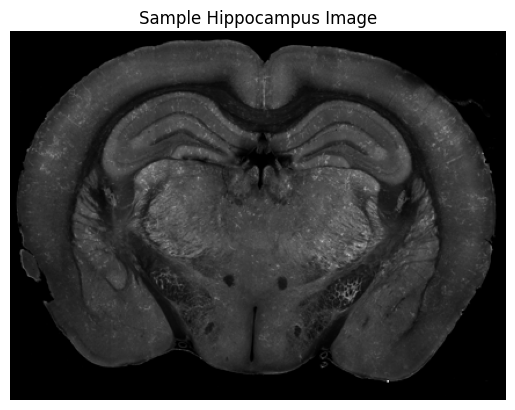

In [4]:
from skimage.io import *

sample_img = imread(r"D:\portfolio\brainglobe-registration\tests\test_images\sample_hipp.tif")
print(sample_img.shape) 

plt.imshow(sample_img,cmap="gray")
plt.title("Sample Hippocampus Image") 
plt.axis("off")
plt.show();

In [5]:
atlas = BrainGlobeAtlas("allen_mouse_25um") 
atlas_volume = atlas.reference 
print(atlas_volume.shape)  


(528, 320, 456)


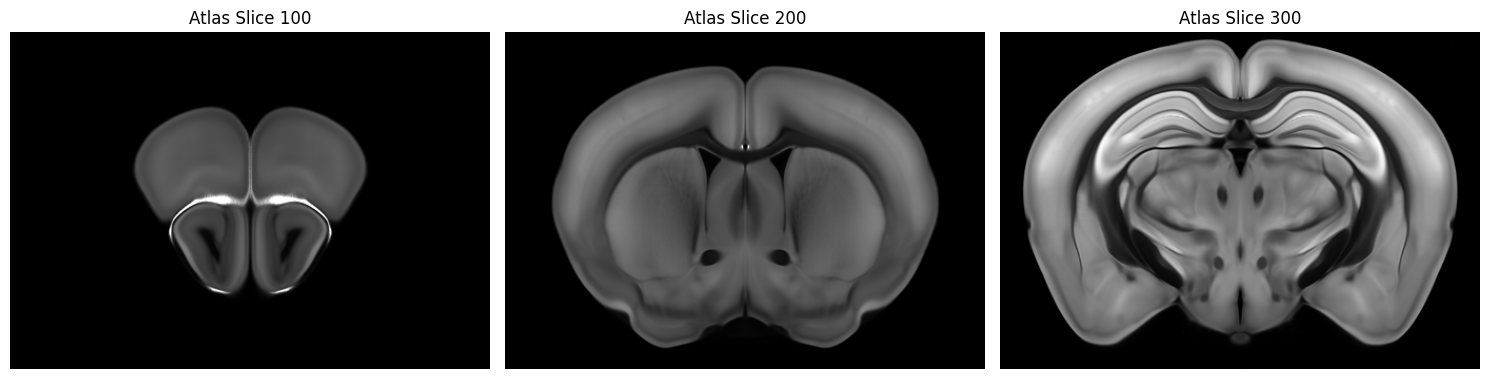

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
slice_indices = [100, 200, 300]  # Adjust based on the atlas
for i, slice_idx in enumerate(slice_indices):
    axes[i].imshow(atlas_volume[slice_idx], cmap='gray')
    axes[i].set_title(f"Atlas Slice {slice_idx}")
    axes[i].axis('off')
plt.tight_layout()
plt.show(); 

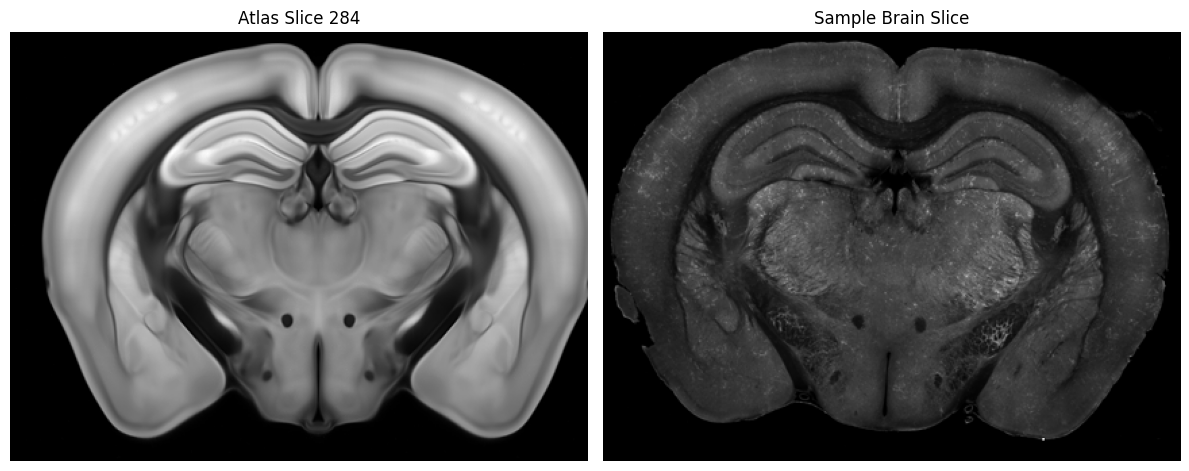

Sample Image Shape: (318, 428)
Reference Slice Shape: (318, 428)


In [7]:
#Metrics 
reference_slice_idx = 284 # change maybe 
reference_slice = atlas_volume[reference_slice_idx]  

# Make sure dimensions match (crop or resize as needed)
min_height = min(sample_img.shape[0], reference_slice.shape[0])
min_width = min(sample_img.shape[1], reference_slice.shape[1])
sample_img_cropped = sample_img[:min_height, :min_width]
reference_slice_cropped = reference_slice[:min_height, :min_width]

# Show the images side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(reference_slice_cropped, cmap='gray')
axes[0].set_title(f"Atlas Slice {reference_slice_idx}")
axes[0].axis('off')
axes[1].imshow(sample_img_cropped, cmap='gray')
axes[1].set_title("Sample Brain Slice")
axes[1].axis('off')
plt.tight_layout()
plt.show() 

print(f"Sample Image Shape: {sample_img_cropped.shape}")
print(f"Reference Slice Shape: {reference_slice_cropped.shape}")

In [8]:
# Calculate and display each metric
metrics = {
    "Normalized Cross-Correlation": normalized_cross_correlation(reference_slice_cropped, sample_img_cropped),
    "Mutual Information": mutual_information(reference_slice_cropped, sample_img_cropped),
    "Structural Similarity Index": structural_similarity_index(reference_slice_cropped, sample_img_cropped),
    #"Elastix Metric": elastix_metric(reference_slice_cropped, sample_img_cropped)
} 


In [9]:
# Display the metric values
for name, value in metrics.items():
    print(f"{name}: {value:.4f}") 

Normalized Cross-Correlation: 0.5876
Mutual Information: 1.0710
Structural Similarity Index: 0.3082


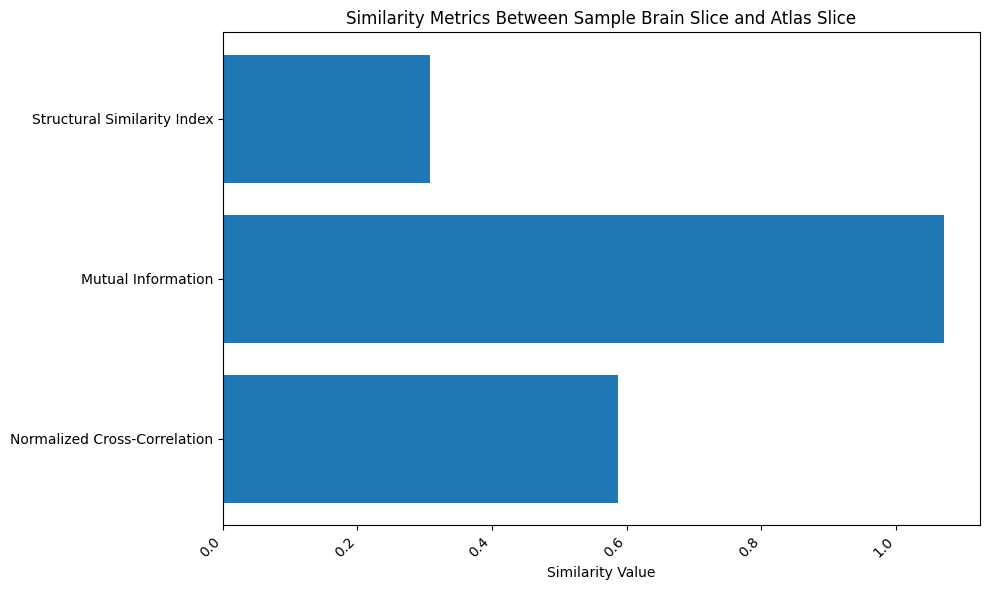

In [12]:
# Plot the metrics
plt.figure(figsize=(10, 6))
plt.barh(metrics.keys(), metrics.values())
plt.title("Similarity Metrics Between Sample Brain Slice and Atlas Slice")
plt.xticks(rotation=45, ha='right')
plt.xlabel("Similarity Value") 
plt.tight_layout()
plt.show(); 

In [13]:
#Compare multiple slices 
slice_range = (100, 400)  # Adjust based on your atlas 
similarities = compare_image_to_atlas_slices(
    sample_img_cropped, 
    atlas_volume, 
    slice_range=slice_range,
    metric="ncc"  # Try different metrics
)

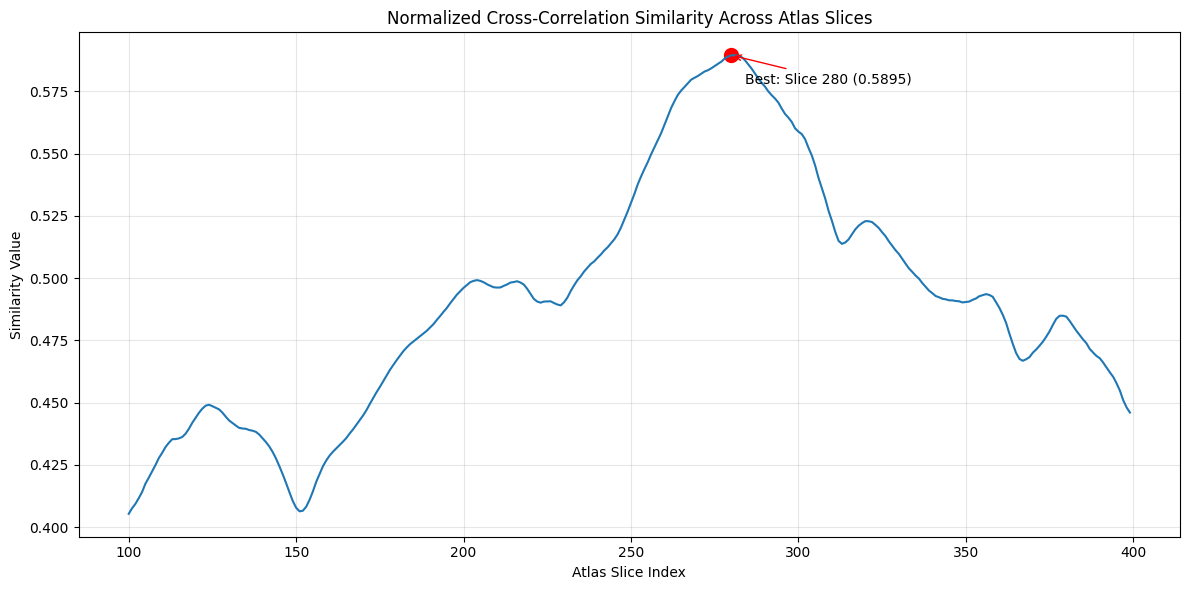

In [14]:
# Plot the similarities
plt.figure(figsize=(12, 6))
plt.plot(similarities.keys(), similarities.values())
plt.title("Normalized Cross-Correlation Similarity Across Atlas Slices")
plt.xlabel("Atlas Slice Index")
plt.ylabel("Similarity Value")
plt.grid(True, alpha=0.3)

# Highlight the best slice
best_slice = max(similarities.items(), key=lambda x: x[1])
plt.scatter(best_slice[0], best_slice[1], color='red', s=100)
plt.annotate(f"Best: Slice {best_slice[0]} ({best_slice[1]:.4f})",
             (best_slice[0], best_slice[1]),
             xytext=(10, -20),
             textcoords="offset points",
             arrowprops=dict(arrowstyle="->", color='red'))

plt.tight_layout()
plt.show(); 

In [15]:
print(f"Best matching slice: {best_slice[0]} with similarity value: {best_slice[1]:.4f}") 

Best matching slice: 280 with similarity value: 0.5895


In [19]:
# Use our utility function to find the best slice
best_slice_idx = find_best_atlas_slice(
    sample_img_cropped,
    atlas_volume,
    metric="ncc",
    search_range=(100, 400),  # Adjust based on your atlas
    search_step=1  # Check every 5th slice for speed
) 

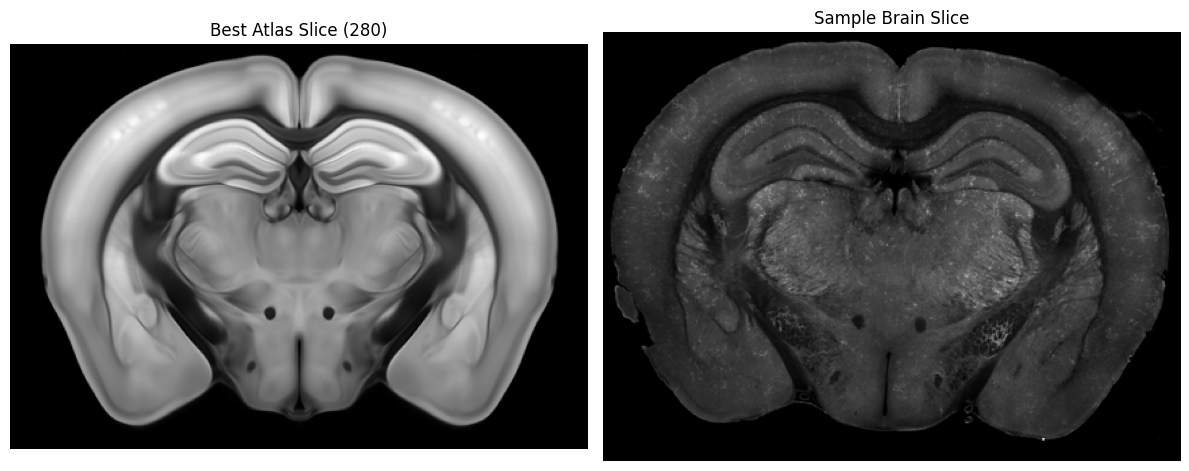

Automated selection found slice 280 as the best match


In [20]:
# Show the best matching slice
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(atlas_volume[best_slice_idx], cmap='gray')
axes[0].set_title(f"Best Atlas Slice ({best_slice_idx})")
axes[0].axis('off')
axes[1].imshow(sample_img_cropped, cmap='gray')
axes[1].set_title("Sample Brain Slice")
axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f"Automated selection found slice {best_slice_idx} as the best match")

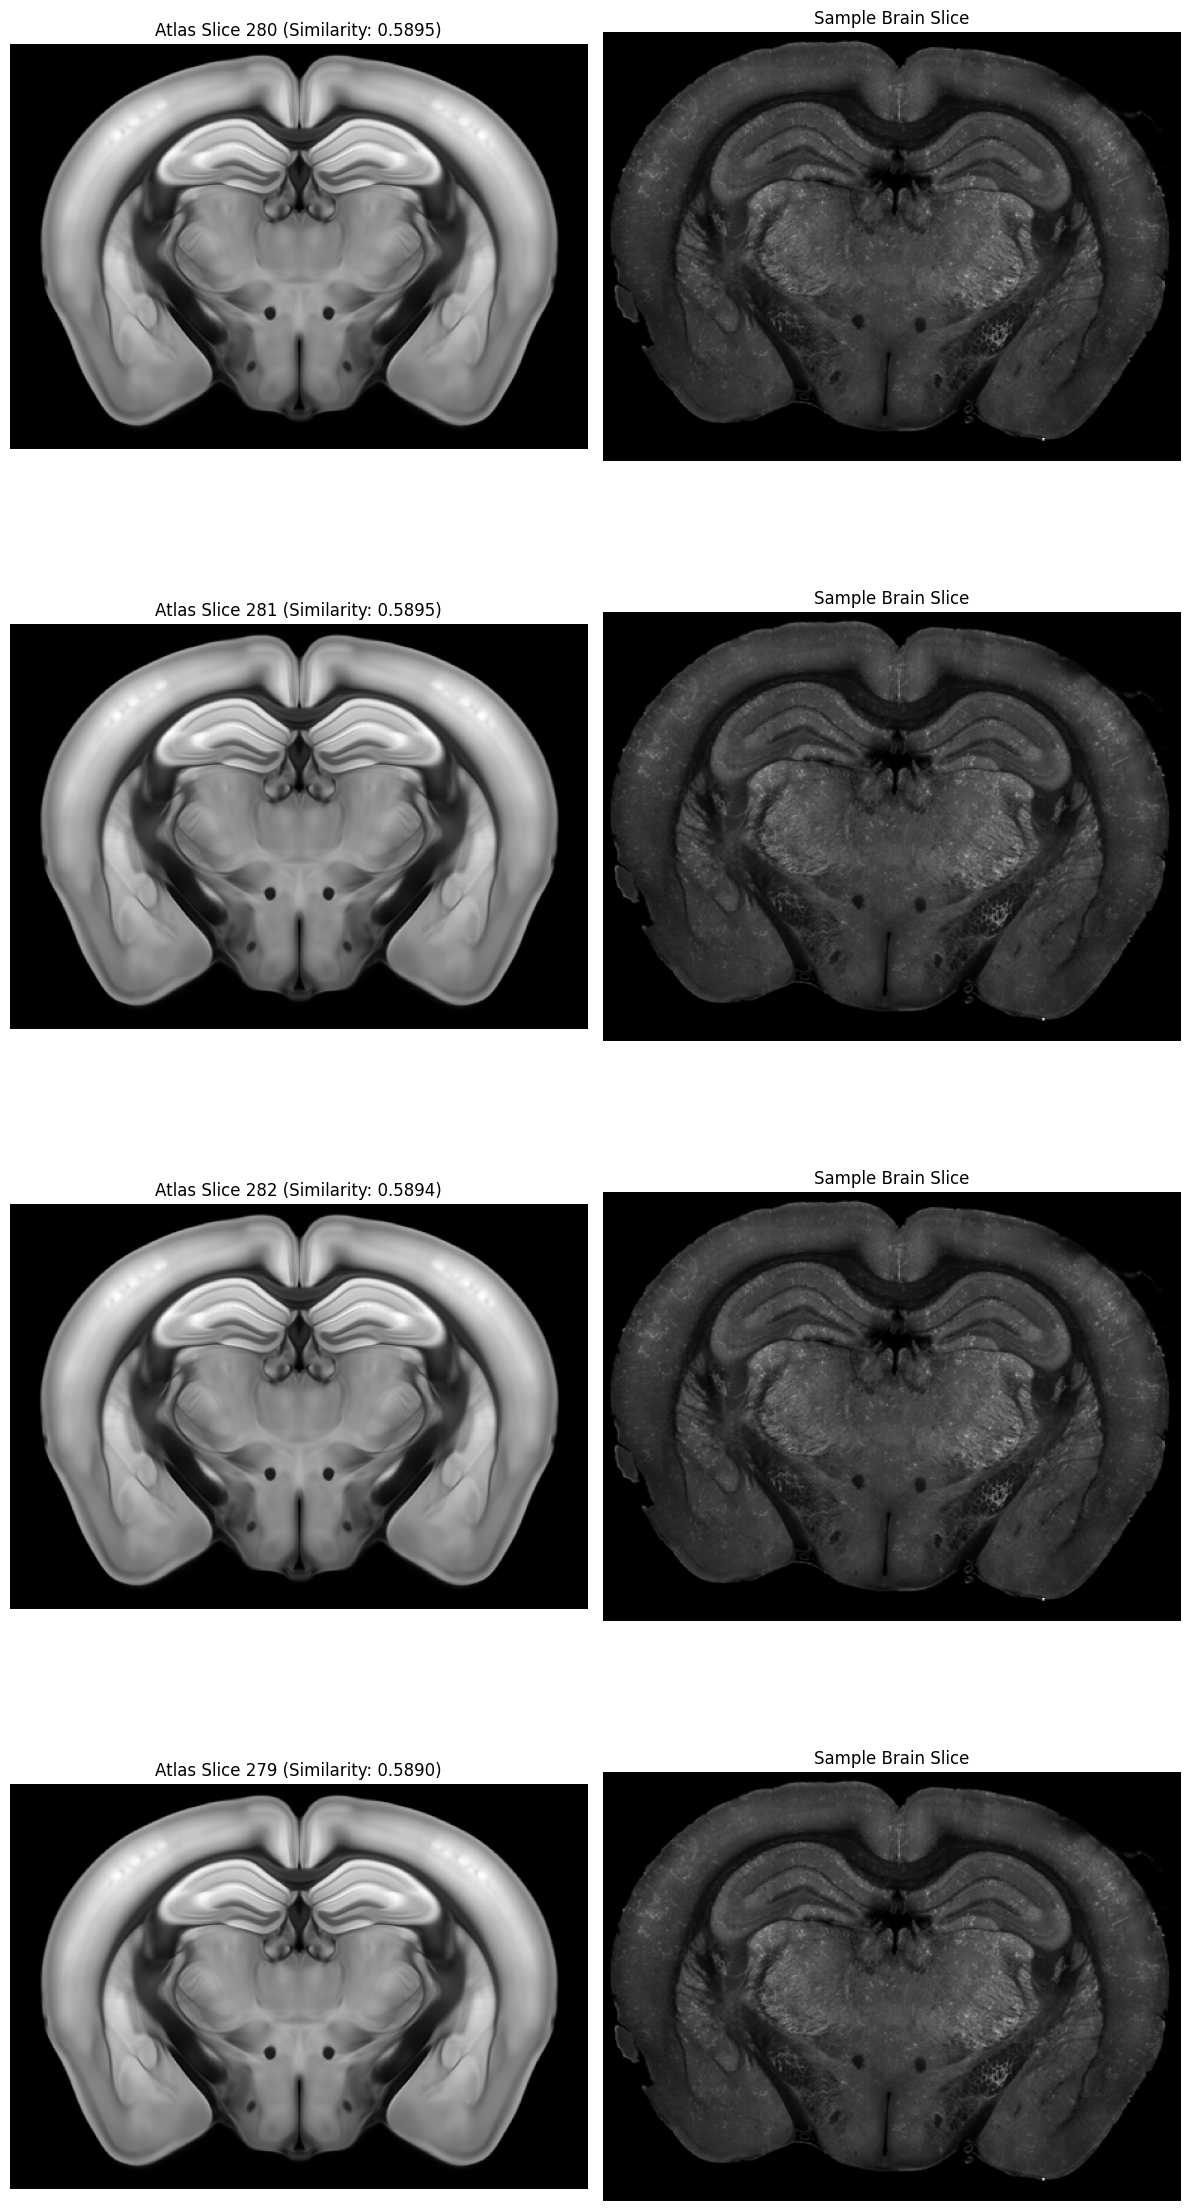

In [22]:
# Compare top N slices visually
top_n = 4
top_slices = sorted(similarities.items(), key=lambda x: x[1], reverse=True)[:top_n]

fig, axes = plt.subplots(top_n, 2, figsize=(12, 6*top_n))
for i, (slice_idx, similarity) in enumerate(top_slices):
    # Show atlas slice
    axes[i, 0].imshow(atlas_volume[slice_idx], cmap='gray')
    axes[i, 0].set_title(f"Atlas Slice {slice_idx} (Similarity: {similarity:.4f})")
    axes[i, 0].axis('off')
    
    # Show sample image for comparison
    axes[i, 1].imshow(sample_img_cropped, cmap='gray')
    axes[i, 1].set_title("Sample Brain Slice")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

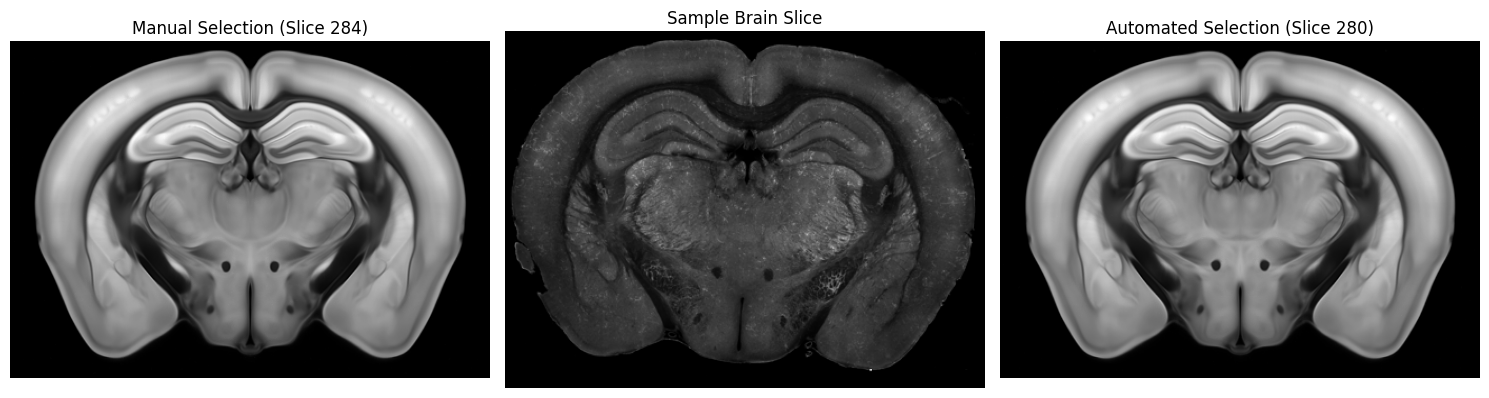

In [15]:
 # Compare manual selection vs automated selection
manual_slice_idx = 284 #selected from the image in the repo
auto_slice_idx = 280

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Manual selection
axes[0].imshow(atlas_volume[manual_slice_idx], cmap='gray')
axes[0].set_title(f"Manual Selection (Slice {manual_slice_idx})")
axes[0].axis('off')

# Sample image
axes[1].imshow(sample_img_cropped, cmap='gray')
axes[1].set_title("Sample Brain Slice")
axes[1].axis('off')

# Automated selection
axes[2].imshow(atlas_volume[auto_slice_idx], cmap='gray')
axes[2].set_title(f"Automated Selection (Slice {auto_slice_idx})")
axes[2].axis('off')

plt.tight_layout()
plt.show()

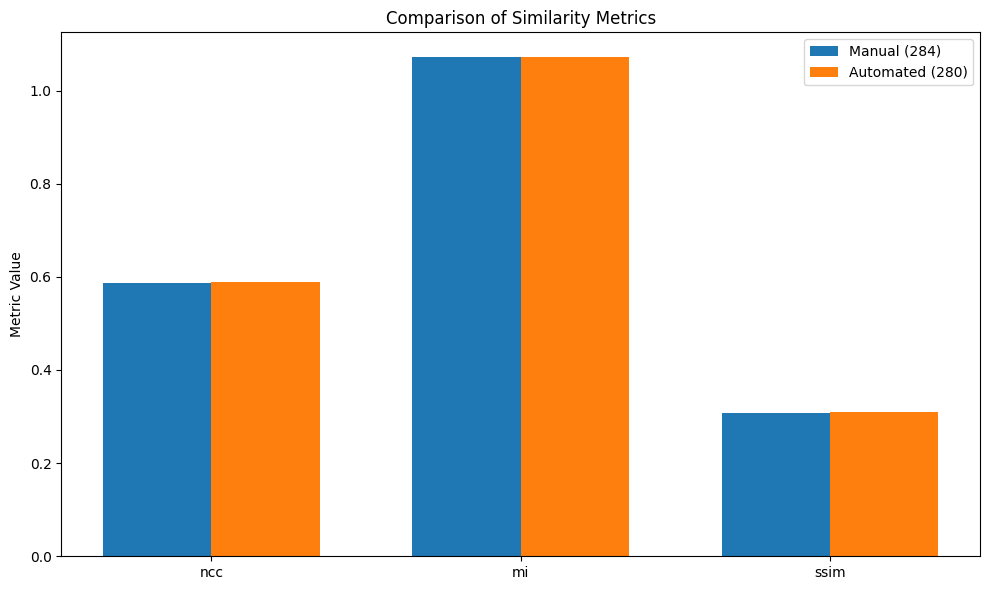

In [18]:
# Calculate metrics for both slices
manual_metrics = {
    "ncc": normalized_cross_correlation(atlas_volume[manual_slice_idx], sample_img_cropped),
    "mi": mutual_information(atlas_volume[manual_slice_idx], sample_img_cropped),
    "ssim": structural_similarity_index(atlas_volume[manual_slice_idx], sample_img_cropped)
}

auto_metrics = {
    "ncc": normalized_cross_correlation(atlas_volume[auto_slice_idx], sample_img_cropped),
    "mi": mutual_information(atlas_volume[auto_slice_idx], sample_img_cropped),
    "ssim": structural_similarity_index(atlas_volume[auto_slice_idx], sample_img_cropped)
}

# Display comparison
metrics = ["ncc", 'mi', 'ssim']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
manual_bars = ax.bar(x - width/2, [manual_metrics[m] for m in metrics], width, label='Manual (284)')
auto_bars = ax.bar(x + width/2, [auto_metrics[m] for m in metrics], width, label='Automated (280)')

ax.set_ylabel('Metric Value')
ax.set_title('Comparison of Similarity Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

plt.tight_layout()
plt.show();

In [19]:
manual_metrics 

{'ncc': np.float32(0.587574),
 'mi': np.float64(1.07104983479763),
 'ssim': np.float64(0.30818949059070133)}

In [20]:
auto_metrics 

{'ncc': np.float32(0.5895129),
 'mi': np.float64(1.0714737536605434),
 'ssim': np.float64(0.3087395432541972)}